# EDA — randomBlocks_all dataset

Exploring sample counts per configuration family, broken down by node type (waypoints, rrt, lgp).

In [4]:
import os
import pandas as pd

DATA_DIR = os.path.dirname(os.path.abspath("eda.ipynb"))

# Load each node-type CSV
dfs = {
    "lgp":       pd.read_csv(os.path.join(DATA_DIR, "aggregated_lgp_by_plan.csv"),    usecols=["file_id"]),
    "rrt":       pd.read_csv(os.path.join(DATA_DIR, "aggregated_rrt_by_action.csv"),  usecols=["file_id"]),
    "waypoints": pd.read_csv(os.path.join(DATA_DIR, "aggregated_waypoints.csv"),      usecols=["file_id"]),
}

# Extract family (everything before '__')
for name, df in dfs.items():
    df["family"] = df["file_id"].str.split("__").str[0]

print("Row counts per CSV:")
for name, df in dfs.items():
    print(f"  {name:>10}: {len(df):,} rows")

Row counts per CSV:
         lgp: 4,446 rows
         rrt: 38,390 rows
   waypoints: 4,456 rows


## Samples per family — overall (all node types combined)

In [5]:
all_families = pd.concat(
    [df[["family"]] for df in dfs.values()],
    ignore_index=True
)

overall = (
    all_families["family"]
    .value_counts()
    .rename_axis("family")
    .rename("total_samples")
    .sort_index()
    .to_frame()
)

print("=== Overall samples per family (all node types) ===")
print(overall.to_string())
overall

=== Overall samples per family (all node types) ===
                                           total_samples
family                                                  
randomBlocks_2blocks_2goals_2blockedgoals          11311
randomBlocks_3blocks_3goals_2blockedgoals          12794
randomBlocks_4blocks_4goals_1blockedgoals          23187


,total_samples
family,
randomBlocks_2blocks_2goals_2blockedgoals,11311
randomBlocks_3blocks_3goals_2blockedgoals,12794
randomBlocks_4blocks_4goals_1blockedgoals,23187


## Samples per family — broken down by node type

In [6]:
per_type = pd.concat(
    [
        df["family"].value_counts().rename(name)
        for name, df in dfs.items()
    ],
    axis=1,
).sort_index()

per_type.index.name = "family"
per_type = per_type.fillna(0).astype(int)

print("=== Samples per family per node type ===")
print(per_type.to_string())
per_type

=== Samples per family per node type ===
                                            lgp    rrt  waypoints
family                                                           
randomBlocks_2blocks_2goals_2blockedgoals  1103   9110       1098
randomBlocks_3blocks_3goals_2blockedgoals  1256  10286       1252
randomBlocks_4blocks_4goals_1blockedgoals  2087  18994       2106


,lgp,rrt,waypoints
family,,,
randomBlocks_2blocks_2goals_2blockedgoals,1103,9110,1098
randomBlocks_3blocks_3goals_2blockedgoals,1256,10286,1252
randomBlocks_4blocks_4goals_1blockedgoals,2087,18994,2106


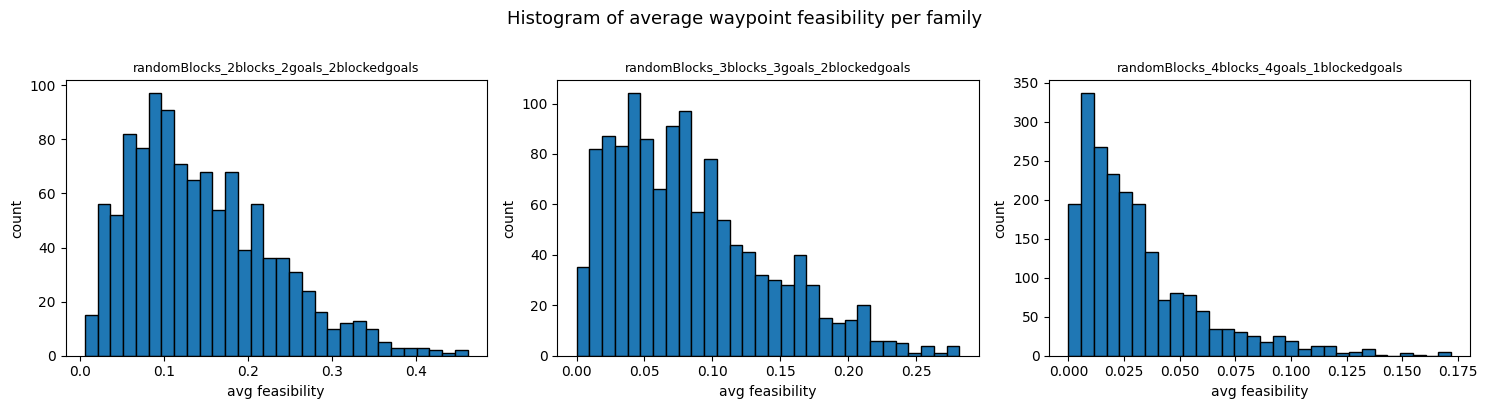

In [7]:
import ast
import matplotlib.pyplot as plt
import numpy as np

# Load waypoints with the feas column
wp = pd.read_csv(os.path.join(DATA_DIR, "aggregated_waypoints.csv"), usecols=["file_id", "feas"])
wp["family"] = wp["file_id"].str.split("__").str[0]

# Parse feas column (stored as a string representation of a list) and compute mean
wp["avg_feas"] = wp["feas"].apply(lambda x: float(np.mean(ast.literal_eval(x))))

families = sorted(wp["family"].unique())
n = len(families)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, family in enumerate(families):
    vals = wp.loc[wp["family"] == family, "avg_feas"]
    axes[i].hist(vals, bins=30, edgecolor="black")
    axes[i].set_title(family, fontsize=9)
    axes[i].set_xlabel("avg feasibility")
    axes[i].set_ylabel("count")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Histogram of average waypoint feasibility per family", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
